In [2]:
import pandas as pd
import numpy as np

In [3]:
#import and clean necessary csvs
celltypes = pd.read_csv("primary_list.csv").drop(columns = ["HB type","FAFB NT", "BANC NT", "Coordinates ", "JOA (L+R) influence score", "JOB (L+R) influence score", "JOA L influence", "JOB L influence"])
modeprefs = pd.read_csv("modeprefs.csv")
connections = pd.read_csv("connections_princeton.csv.gz").drop(columns = ["neuropil", "nt_type"])

In [4]:
#simplify celltypes table before merging

id_and_types = celltypes[["Cell type (Lockwood et al)", "Codex June 2024"]]
id_and_types

,Cell type (Lockwood et al),Codex June 2024
0,A1,720575940631693610
1,A1,720575940631200327
2,A1,720575940618522433
3,A1,720575940612001489
4,A1,720575940616313942
...,...,...
904,JO-B,720575940631670584
905,JO-B,720575940617244049
906,JO-B,720575940617407929
907,JO-B,720575940620257216


In [5]:
#merge cell types and connections table
merge1 = connections.merge(id_and_types, how="left", left_on="pre_root_id", right_on="Codex June 2024").drop(columns="Codex June 2024")
conns = merge1.merge(id_and_types, how="left", left_on="post_root_id", right_on="Codex June 2024").drop(columns="Codex June 2024")
conns


,pre_root_id,post_root_id,syn_count,Cell type (Lockwood et al)_x,Cell type (Lockwood et al)_y
0,720575940625363947,720575940623224444,12,NaN,NaN
1,720575940630432382,720575940618518557,67,NaN,NaN
2,720575940627314521,720575940626337738,10,NaN,NaN
3,720575940620280405,720575940620204726,15,NaN,NaN
4,720575940636942447,720575940613789411,1,NaN,NaN
...,...,...,...,...,...
5342441,720575940610739918,720575940617129885,5,NaN,NaN
5342442,720575940653332385,720575940623905719,2,NaN,NaN
5342443,720575940622485887,720575940631031803,9,NaN,NaN
5342444,720575940620020534,720575940636489140,2,NaN,NaN


Columns ending in _x correspond to presynaptic neuron, _y correspond to postsynaptic.

In [6]:
#collapse by cell type and count number of postsynaptic neurons

grouped = (
    conns.groupby(["Cell type (Lockwood et al)_x", "Cell type (Lockwood et al)_y"]).agg(
        total_synapses = ("syn_count", "sum"),
        n_postsyn_neurons=("post_root_id", "nunique")
    ).reset_index()
)

grouped

,Cell type (Lockwood et al)_x,Cell type (Lockwood et al)_y,total_synapses,n_postsyn_neurons
0,A1,A1,651,5
1,A1,AVLP/PVLP_pr01-2,31,3
2,A1,AVLP_pr23,13,1
3,A1,B1-4,19,3
4,A1,B1-6,5,1
...,...,...,...,...
561,vpoIN-3,pC2la,11,2
562,vpoIN-3,pC2lb,42,4
563,vpoIN-3,pMN1,16,2
564,vpoIN-3,pMN2,26,2


In [7]:
#filter for connections with more than 10 synapses/postsynaptic neuron

grouped["syn_per_post_neuron"] = (
    grouped["total_synapses"]/grouped["n_postsyn_neurons"]
)

conns_filtered = grouped[grouped["syn_per_post_neuron"] > 10].sort_values(by="syn_per_post_neuron", ascending=False)
conns_filtered

,Cell type (Lockwood et al)_x,Cell type (Lockwood et al)_y,total_synapses,n_postsyn_neurons,syn_per_post_neuron
281,JO-A,A2,4753,4,1188.250000
297,JO-A,WV-WV-1,2990,3,996.666667
142,B1-2,WV-WV-1,2386,3,795.333333
124,B1-1,WV-WV-1,2284,3,761.333333
292,JO-A,SAD_pr01,1388,2,694.000000
...,...,...,...,...,...
555,vpoIN-2,pC2lb,42,4,10.500000
112,AVLP_pr36/asp10a-2,AVLP_pr36/asp10a-2,21,2,10.500000
562,vpoIN-3,pC2lb,42,4,10.500000
1,A1,AVLP/PVLP_pr01-2,31,3,10.333333


In [8]:
#remove connections onto same cell type

conns_filtered = conns_filtered[conns_filtered["Cell type (Lockwood et al)_x"] != conns_filtered["Cell type (Lockwood et al)_y"]]
conns_filtered

,Cell type (Lockwood et al)_x,Cell type (Lockwood et al)_y,total_synapses,n_postsyn_neurons,syn_per_post_neuron
281,JO-A,A2,4753,4,1188.250000
297,JO-A,WV-WV-1,2990,3,996.666667
142,B1-2,WV-WV-1,2386,3,795.333333
124,B1-1,WV-WV-1,2284,3,761.333333
292,JO-A,SAD_pr01,1388,2,694.000000
...,...,...,...,...,...
64,AVLP_pr05-3,AVLP_pr18-1,21,2,10.500000
555,vpoIN-2,pC2lb,42,4,10.500000
562,vpoIN-3,pC2lb,42,4,10.500000
1,A1,AVLP/PVLP_pr01-2,31,3,10.333333


In [9]:
conns_filtered.to_csv("conns_filtered.csv", index=False)

In [10]:
#rename columns for gephi upload
conns_filtered_g = conns_filtered.rename(columns={
    "Cell type (Lockwood et al)_x":"Source",
    "Cell type (Lockwood et al)_y":"Target",
    "syn_per_post_neuron":"Weight"
})
conns_filtered_g

,Source,Target,total_synapses,n_postsyn_neurons,Weight
281,JO-A,A2,4753,4,1188.250000
297,JO-A,WV-WV-1,2990,3,996.666667
142,B1-2,WV-WV-1,2386,3,795.333333
124,B1-1,WV-WV-1,2284,3,761.333333
292,JO-A,SAD_pr01,1388,2,694.000000
...,...,...,...,...,...
64,AVLP_pr05-3,AVLP_pr18-1,21,2,10.500000
555,vpoIN-2,pC2lb,42,4,10.500000
562,vpoIN-3,pC2lb,42,4,10.500000
1,A1,AVLP/PVLP_pr01-2,31,3,10.333333


In [11]:
conns_filtered_g.to_csv("conns_filtered_g.csv", index=False)

In [12]:
#merge cell type and song mode preference information
celltypes.merge(modeprefs, how="left", left_on="Cell type (Baker et al 2022)", right_on="Dec 2025")

,Neuron name (Baker et al 2022),Cell type (Baker et al 2022),Neuron name (Lockwood et al),Cell type (Lockwood et al),Codex June 2024,NT2026 (FAFB and BANC),Baker et al 2022,Dec 2025,Song type preference of parent cell type
0,A1_L1,A1,A1_R1,A1,720575940631693610,inconclusive,A1,A1,intermediate
1,A1_L2,A1,A1_R2,A1,720575940631200327,inconclusive,A1,A1,intermediate
2,A1_L3,A1,A1_R3,A1,720575940618522433,inconclusive,A1,A1,intermediate
3,A1_R1,A1,A1_L1,A1,720575940612001489,inconclusive,A1,A1,intermediate
4,A1_R2,A1,A1_L2,A1,720575940616313942,inconclusive,A1,A1,intermediate
...,...,...,...,...,...,...,...,...,...
904,NaN,NaN,JO-B_L162,JO-B,720575940631670584,Ach,NaN,NaN,NaN
905,NaN,NaN,JO-B_L163,JO-B,720575940617244049,Ach,NaN,NaN,NaN
906,NaN,NaN,JO-B_L164,JO-B,720575940617407929,Ach,NaN,NaN,NaN
907,NaN,NaN,JO-B_L165,JO-B,720575940620257216,Ach,NaN,NaN,NaN


In [13]:
#create node list for graph

types = celltypes[["Cell type (Baker et al 2022)", "Cell type (Lockwood et al)", "NT2026 (FAFB and BANC)"]]
merge1 = types.merge(modeprefs, how="left", left_on="Cell type (Baker et al 2022)", right_on="Dec 2025")
edit1 = merge1.rename(columns={"Cell type (Baker et al 2022)":"type_baker",
                               "Cell type (Lockwood et al)":"Id",
                       "NT2026 (FAFB and BANC)":"nt",
                       "Song type preference of parent cell type":"mode preference"}).drop_duplicates()
nodelist = edit1.drop(columns=["Baker et al 2022","Dec 2025"])
nodelist

,type_baker,Id,nt,mode preference
0,A1,A1,inconclusive,intermediate
5,A2,A2,Ach,pulse
6,NaN,A2,Ach,NaN
9,B1-1,B1-1,Ach,pulse
21,put_B1,B1-1,Ach,NaN
...,...,...,...,...
492,NaN,aPN3,GLUT,NaN
502,NaN,aPN2,Ach,NaN
506,NaN,aPN2,NaN,NaN
516,NaN,JO-A,Ach,NaN


In [14]:
nodelist.to_csv("nodelist.csv", index=False)

(array([[<Axes: title={'center': 'syn_per_post_neuron'}>]], dtype=object),
 array([[<Axes: title={'center': 'syn_per_post_neuron'}>]], dtype=object))

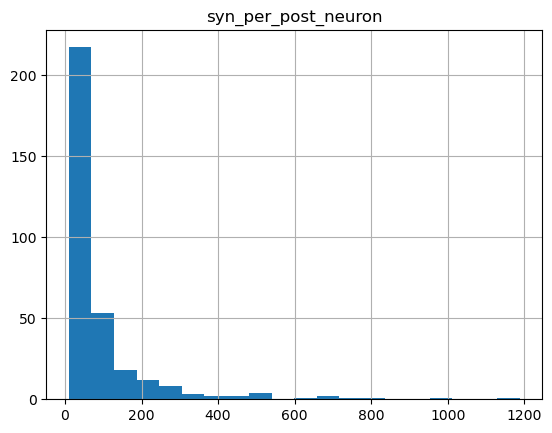

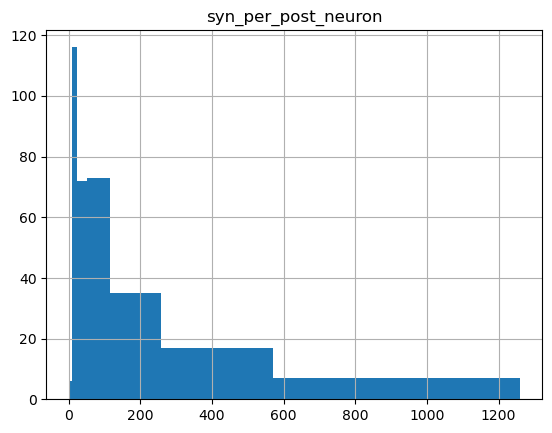

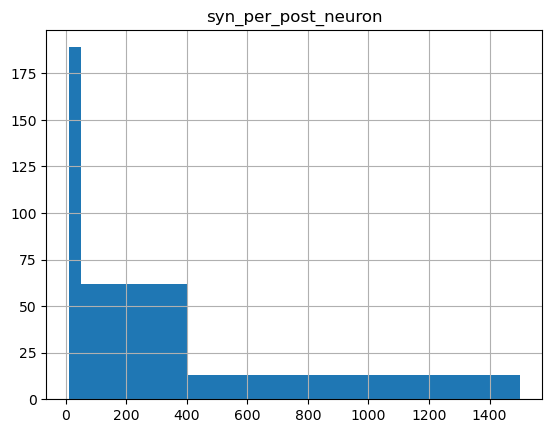

In [15]:
#histograms based on normalized values

hist_linear_norm = conns_filtered.hist(column="syn_per_post_neuron", bins=20) #linear bin distribution

log_bins = np.logspace(0, 3.1, 10) #log bin distribution
hist_log_norm = conns_filtered.hist(column="syn_per_post_neuron", bins=log_bins)

custom_bins = [10, 50, 100, 400, 1500]
hist_custom_norm = conns_filtered.hist(column="syn_per_post_neuron", bins=custom_bins)

hist_linear_norm, hist_log_norm

In [16]:
#get quick stats for network

min = conns_filtered[["syn_per_post_neuron"]].min()
max = conns_filtered[['syn_per_post_neuron']].max()
mean = conns_filtered[['syn_per_post_neuron']].mean()
median = conns_filtered[['syn_per_post_neuron']].median()

print(
    "Min normalized count: "+min,
    "Max normalized count: "+max,
    "Mean normalized count: "+mean,
    "Median normalized count: "+median
)


UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U22'), dtype('float64')) -> None

In [ ]:
#filter for normalized connections above/including 50
conns_above50 = conns_filtered[conns_filtered["syn_per_post_neuron"]>=50].copy()
conns_above50.to_csv("conns_above50.csv", index=False)

In [ ]:
#change column names for gephi upload
conns_above50_g = conns_above50.rename(columns={"Cell type (Lockwood et al)_x":"Source",
                                                "Cell type (Lockwood et al)_y":"Target",
                                                "syn_per_post_neuron":"Weight"})
conns_above50_g

,Source,Target,total_synapses,n_postsyn_neurons,Weight
193,B1-5,WED_pr02,6248,10,624.800000
155,B1-3,WED_pr02,5537,14,395.500000
281,JO-A,A2,4753,4,1188.250000
141,B1-2,WED_pr02,4316,16,269.750000
121,B1-1,WED-VLP-1,3640,22,165.454545
...,...,...,...,...,...
243,B1-u,WV-WV-3,100,2,50.000000
254,B2,WV-WV-3,85,1,85.000000
480,WV-WV-4,WV-WV-1,62,1,62.000000
300,JO-A,WV-WV-4,55,1,55.000000


In [ ]:
conns_above50_g.to_csv("conns_above50_g.csv", index=False)

In [ ]:
#create separate sheet for reciprocal connections
conns_above50_g['pair'] = conns_above50_g.apply(lambda row: frozenset([row['Source'], row['Target']]), axis=1)

edges = set(zip(conns_above50_g['Source'], conns_above50_g['Target']))

conns_above50_g['is_reciprocal'] = conns_above50_g.apply(lambda row: (row['Target'], row['Source']) in edges and row['Source'] != row['Target'], axis=1)

reciprocal_df = conns_above50_g[conns_above50_g['is_reciprocal']].reset_index()

In [ ]:
reciprocal_df

,index,Source,Target,total_synapses,n_postsyn_neurons,Weight,pair,is_reciprocal
0,193,B1-5,WED_pr02,6248,10,624.800000,"(B1-5, WED_pr02)",True
1,155,B1-3,WED_pr02,5537,14,395.500000,"(B1-3, WED_pr02)",True
2,141,B1-2,WED_pr02,4316,16,269.750000,"(B1-2, WED_pr02)",True
3,453,WV-WV-2,WED_pr02,2243,21,106.809524,"(WED_pr02, WV-WV-2)",True
4,437,WV-WV-1,WED_pr02,2011,21,95.761905,"(WED_pr02, WV-WV-1)",True
5,415,WED_pr02,WED-VLP-1,1757,22,79.863636,"(WED-VLP-1, WED_pr02)",True
6,9,A2,AVLP_pr01-1,1444,10,144.400000,"(A2, AVLP_pr01-1)",True
7,406,WED_pr02,B1-2,1303,16,81.437500,"(B1-2, WED_pr02)",True
8,420,WED_pr02,WV-WV-2,1182,6,197.000000,"(WV-WV-2, WED_pr02)",True
9,387,WED-VLP-2,WED_pr02,982,9,109.111111,"(WED-VLP-2, WED_pr02)",True


In [ ]:
reciprocal_df.to_csv("reciprocal_conns.csv", index=False)